In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [54]:
# Loading Iris Dataset
data = pd.read_csv("../datasets/iris.csv")
df = pd.DataFrame(data)

df.drop(['Id'], axis=1, inplace=True)

df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


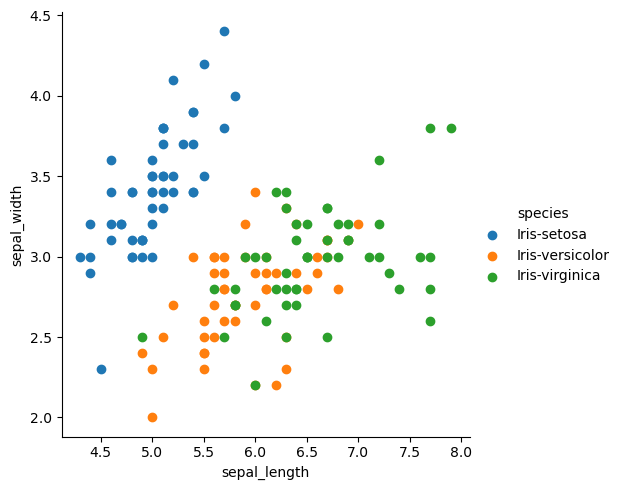

In [55]:
sb.FacetGrid(data,hue="species", height=5).map(plt.scatter, "sepal_length", "sepal_width").add_legend()
plt.show()

In [56]:
# Prepare the data
x = df.iloc[:, 0:4]
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [57]:
# Prepare the target variable
target = df.iloc[:, 4]
target

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: species, Length: 150, dtype: object

In [58]:
def PCA(X, n_components):
    # Step 1: Standardize the data
    X_meaned = X - np.mean(X , axis = 0)
    
    # Step 2: Calculate the covariance matrix
    cov_mat = np.cov(X_meaned , rowvar = False)
    
    # Step 3: Calculate the eigenvalues and eigenvectors
    eigen_values , eigen_vectors = np.linalg.eigh(cov_mat)
    
    # Step 4: Sort the eigenvalues in descending order
    sorted_index = np.argsort(eigen_values)[::-1]
    sorted_eigenvalue = eigen_values[sorted_index]
    
    # Similarly sort the eigenvectors
    sorted_eigenvectors = eigen_vectors[:,sorted_index]
    
    # Step 5: Select the first n eigenvectors (n is desired dimension)
    eigenvector_subset = sorted_eigenvectors[:,0:n_components]
    
    # Step 6: Transform the data 
    X_reduced = np.dot(eigenvector_subset.transpose() , X_meaned.transpose() ).transpose()
    
    return X_reduced

In [60]:
# Applying it to PCA Function
mat_reduced = PCA(x, 2)

# Creating a DataFrame with the reduced data
prinicipal_df = pd.DataFrame(mat_reduced, columns=['PC1', 'PC2'])

# Concat it with target variable to create a complete Dataset
principalDf = pd.concat([prinicipal_df, pd.DataFrame(target)], axis=1)

print(principalDf.head(5))

        PC1       PC2      species
0  2.684207  0.326607  Iris-setosa
1  2.715391 -0.169557  Iris-setosa
2  2.889820 -0.137346  Iris-setosa
3  2.746437 -0.311124  Iris-setosa
4  2.728593  0.333925  Iris-setosa


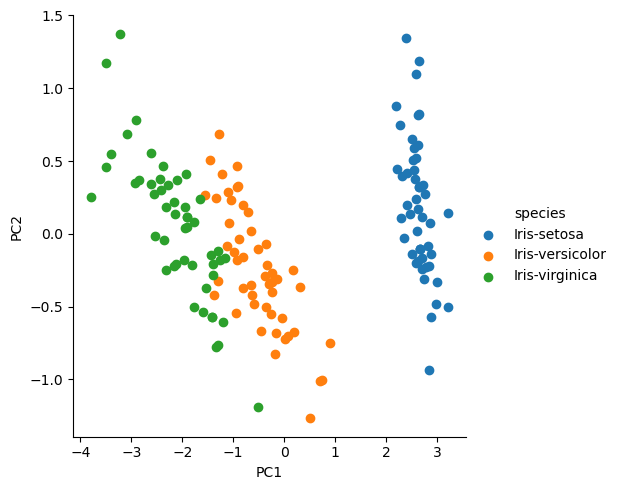

In [62]:
sb.FacetGrid(principalDf,hue="species", height=5).map(plt.scatter, "PC1", "PC2").add_legend()
plt.show()

<Axes: xlabel='PC1', ylabel='PC2'>

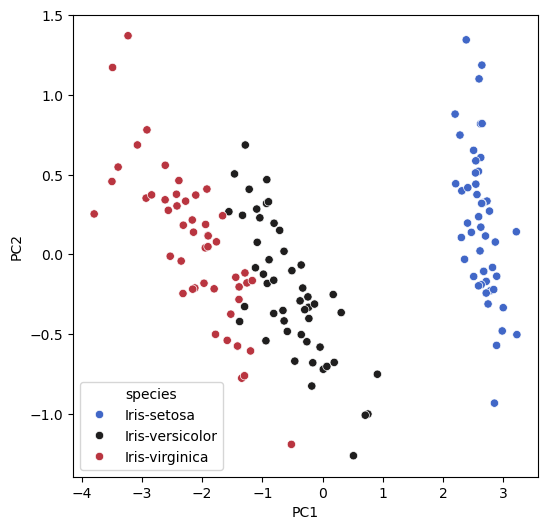

In [63]:
plt.figure(figsize=(6,6))
sb.scatterplot(data=principalDf, x="PC1", y="PC2", hue="species", palette="icefire")